# Notebook 03 — Lead Time & Delivery Bottleneck
**Tujuan:** Identifikasi di mana keterlambatan terjadi paling banyak — shipping mode, market, region, kategori.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

OUT     = Path('../output')
FIGURES = OUT / 'figures'

BLUE  = '#2563EB'
RED   = '#DC2626'
AMBER = '#F59E0B'
GRAY  = '#6B7280'
LIGHT = '#93C5FD'
sns.set_theme(style='whitegrid', font_scale=1.1)

df = pd.read_parquet(OUT / 'df_clean.parquet')
print(f'Loaded: {len(df):,} | Late rate: {df["is_late"].mean():.1%}')

Loaded: 180,519 | Late rate: 54.8%


## A. On-Time Delivery Overview

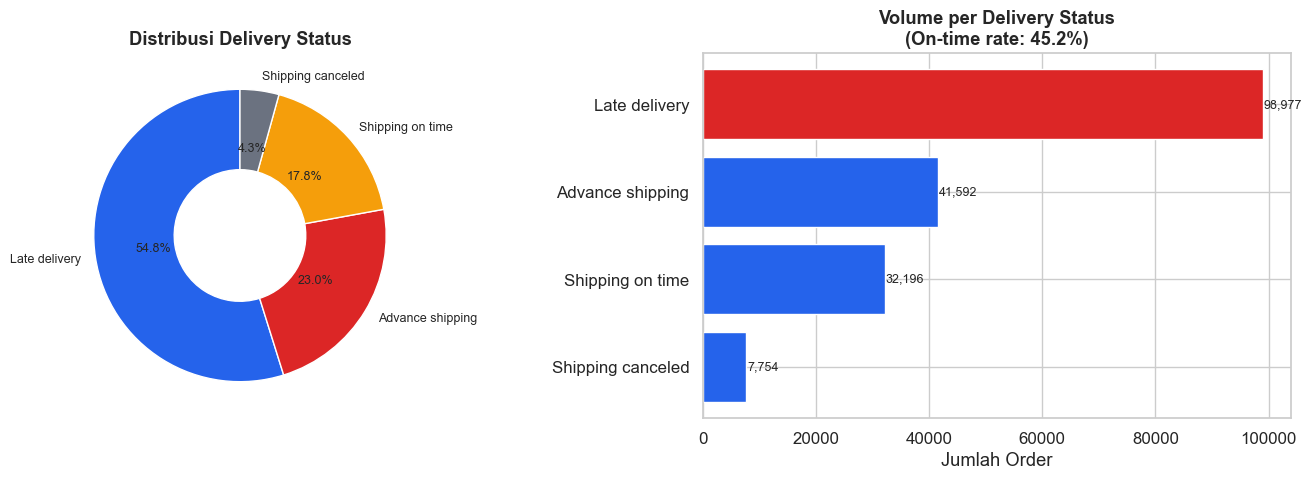

Saved: C_delivery_overview.png


In [2]:
# Delivery status distribution
deliv_col = [c for c in df.columns if 'delivery_status' in c][0]
status_dist = df[deliv_col].value_counts()
on_time_rate = 1 - df['is_late'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Donut chart status
colors_status = [BLUE, RED, AMBER, GRAY]
axes[0].pie(status_dist.values, labels=status_dist.index,
            autopct='%1.1f%%', colors=colors_status[:len(status_dist)],
            wedgeprops={'width': 0.55}, startangle=90,
            textprops={'fontsize': 9})
axes[0].set_title('Distribusi Delivery Status', fontweight='bold')

# Bar chart
bar_c = [RED if 'Late' in s else BLUE for s in status_dist.index]
axes[1].barh(status_dist.index[::-1], status_dist.values[::-1], color=bar_c[::-1])
axes[1].set_xlabel('Jumlah Order')
axes[1].set_title(f'Volume per Delivery Status\n(On-time rate: {on_time_rate:.1%})', fontweight='bold')
for i, v in enumerate(status_dist.values[::-1]):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'C_delivery_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: C_delivery_overview.png')

## B. Late Rate per Shipping Mode & Market

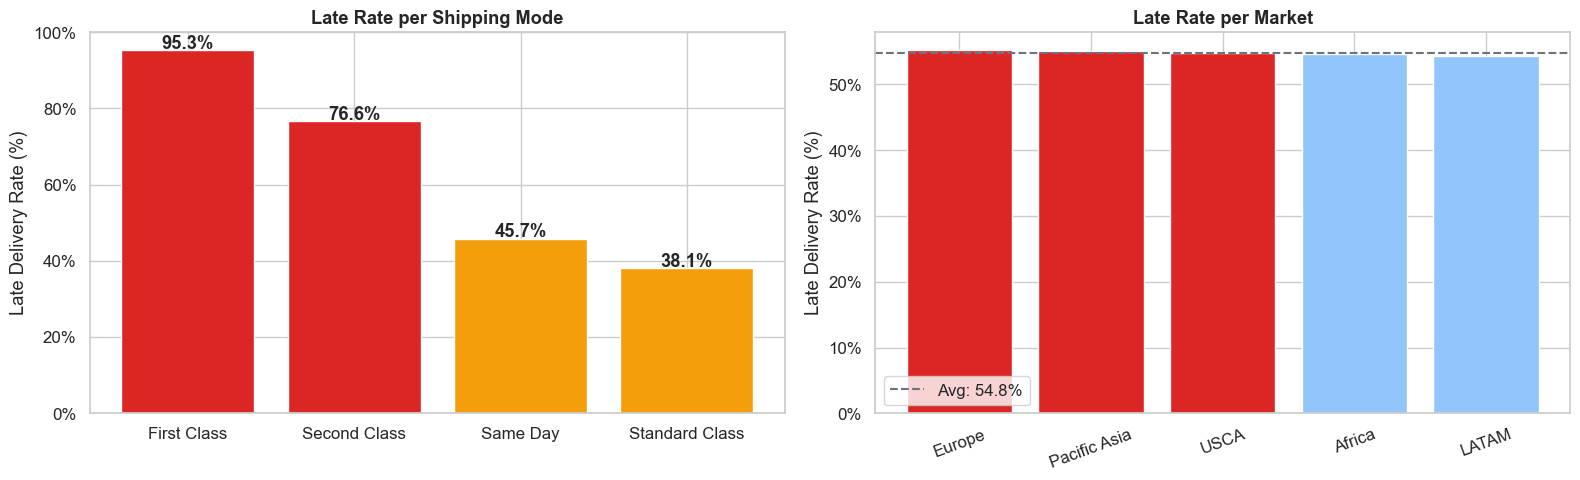

Saved: D_late_by_mode_market.png


In [3]:
mode_late = df.groupby('shipping_mode').agg(
    late_rate     = ('is_late', 'mean'),
    avg_actual    = ('actual_lead_time', 'mean'),
    avg_scheduled = ('scheduled_lead_time', 'mean')
).sort_values('late_rate', ascending=False).reset_index()

market_late = df.groupby('market')['is_late'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Late rate per shipping mode
colors_mode = [RED if v > 0.5 else AMBER if v > 0.3 else BLUE
               for v in mode_late['late_rate']]
bars = axes[0].bar(mode_late['shipping_mode'], mode_late['late_rate'] * 100,
                   color=colors_mode)
axes[0].set_ylabel('Late Delivery Rate (%)')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_title('Late Rate per Shipping Mode', fontweight='bold')
for bar, v in zip(bars, mode_late['late_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v*100 + 0.5,
                 f'{v:.1%}', ha='center', fontweight='bold')

# Late rate per market
colors_mkt = [RED if v > market_late.mean() else LIGHT for v in market_late.values]
axes[1].bar(market_late.index, market_late.values * 100, color=colors_mkt)
axes[1].set_ylabel('Late Delivery Rate (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_title('Late Rate per Market', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(market_late.mean() * 100, color=GRAY, linestyle='--',
                linewidth=1.5, label=f'Avg: {market_late.mean():.1%}')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'D_late_by_mode_market.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: D_late_by_mode_market.png')

## C. Avg Lead Time: Actual vs Scheduled per Shipping Mode

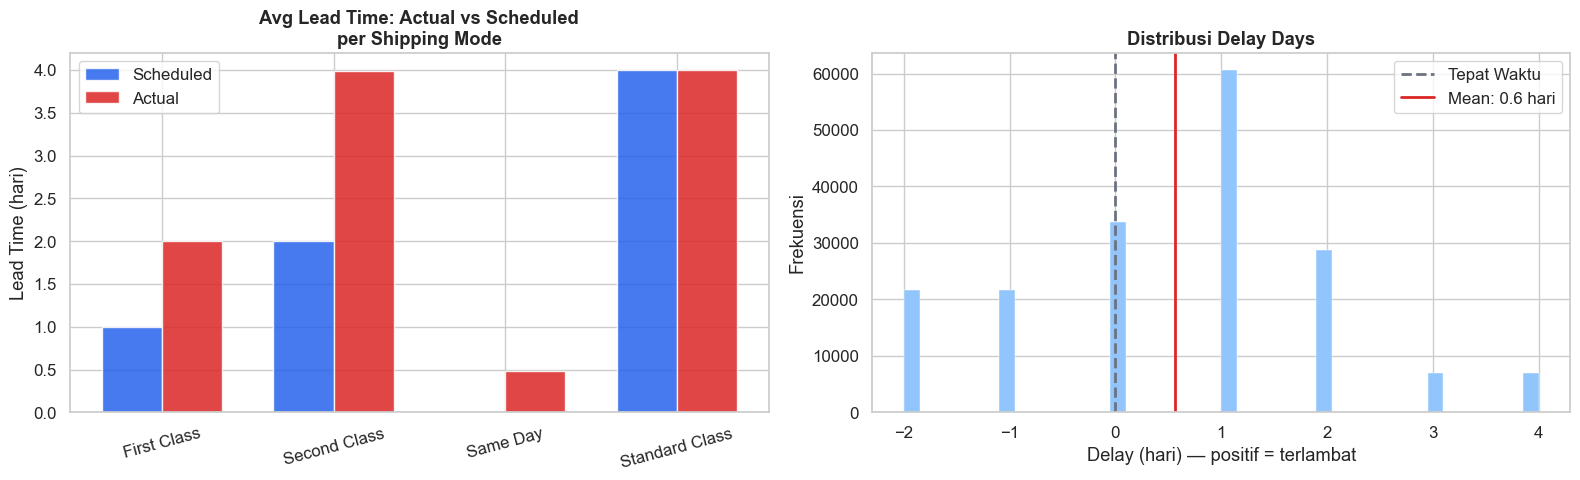

Saved: E_leadtime_analysis.png


In [4]:
x = np.arange(len(mode_late))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar actual vs scheduled
axes[0].bar(x - w/2, mode_late['avg_scheduled'], w, label='Scheduled', color=BLUE, alpha=0.85)
axes[0].bar(x + w/2, mode_late['avg_actual'],    w, label='Actual',    color=RED,  alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(mode_late['shipping_mode'], rotation=15)
axes[0].set_ylabel('Lead Time (hari)')
axes[0].set_title('Avg Lead Time: Actual vs Scheduled\nper Shipping Mode', fontweight='bold')
axes[0].legend()

# Distribusi delay_days
delay_data = df['delay_days'].clip(-5, 15)
axes[1].hist(delay_data, bins=40, color=LIGHT, edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color=GRAY, linestyle='--', linewidth=2, label='Tepat Waktu')
axes[1].axvline(delay_data.mean(), color=RED, linewidth=2,
                label=f'Mean: {delay_data.mean():.1f} hari')
axes[1].set_xlabel('Delay (hari) — positif = terlambat')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Delay Days', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'E_leadtime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: E_leadtime_analysis.png')

## D. Late Rate per Region & Category (Top 10)

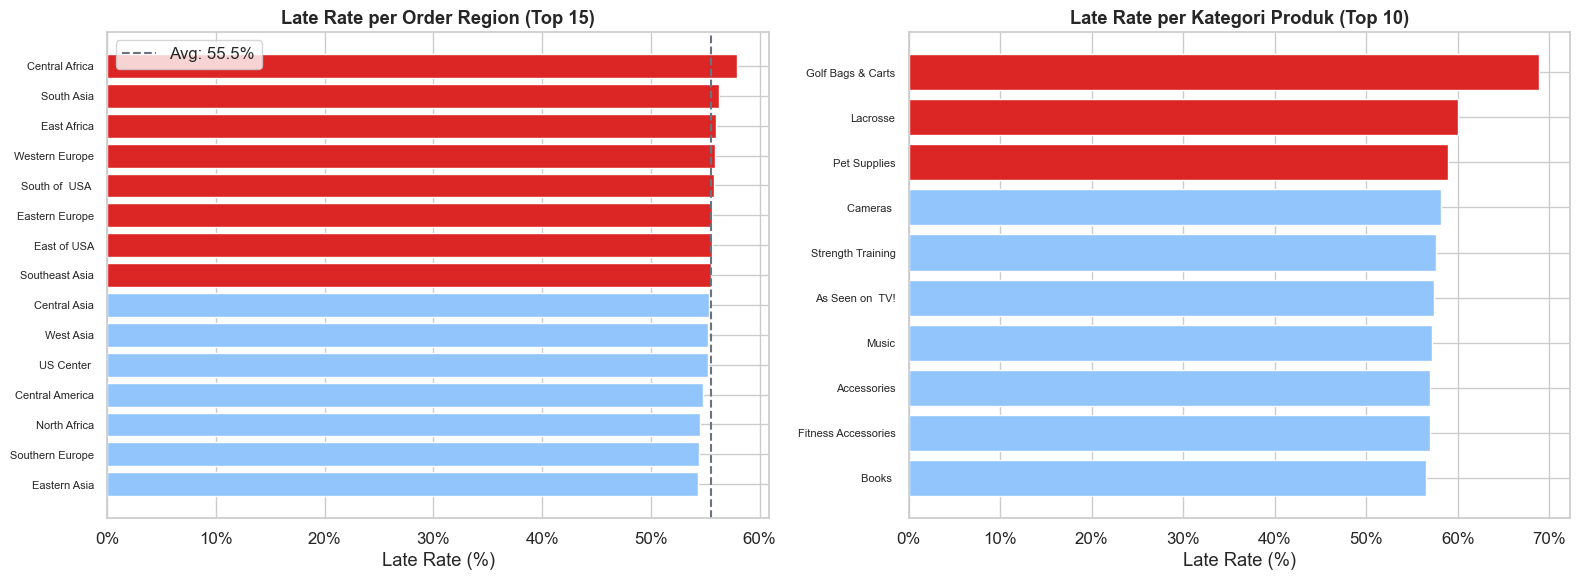

Saved: F_late_region_category.png


In [5]:
region_col = [c for c in df.columns if 'order_region' in c or 'region' in c][0]

region_late = (
    df.groupby(region_col)['is_late']
    .agg(['mean', 'count'])
    .query('count >= 100')
    .sort_values('mean', ascending=False)
    .head(15)
)

cat_late = (
    df.groupby('category_name')['is_late']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Late rate per region
avg_region = region_late['mean'].mean()
colors_reg = [RED if v > avg_region else LIGHT for v in region_late['mean']]
axes[0].barh(region_late.index[::-1], region_late['mean'].values[::-1] * 100,
             color=colors_reg[::-1])
axes[0].axvline(avg_region * 100, color=GRAY, linestyle='--', linewidth=1.5,
                label=f'Avg: {avg_region:.1%}')
axes[0].set_xlabel('Late Rate (%)')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_title('Late Rate per Order Region (Top 15)', fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)
axes[0].legend()

# Late rate per category
colors_cat = [RED if v > cat_late.mean() else LIGHT for v in cat_late.values]
axes[1].barh(cat_late.index[::-1], cat_late.values[::-1] * 100, color=colors_cat[::-1])
axes[1].set_xlabel('Late Rate (%)')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_title('Late Rate per Kategori Produk (Top 10)', fontweight='bold')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES / 'F_late_region_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: F_late_region_category.png')